##**Context**

There is a huge demand for used cars in the Indian Market today. As sales of new cars have slowed down in the recent past, the pre-owned car market has continued to grow over the past few years and is now larger than the new car market. Cars4U is a budding tech start-up that aims to find footholes in this market.

In 2018-19, while new car sales were recorded at 3.6 million units, around 4 million second-hand cars were bought and sold. There is a slowdown in new car sales and that could mean that the demand is shifting towards the pre-owned market. In fact, some car owners replace their old vehicles with pre-owned cars instead of buying a new automobile.

Unlike new cars, where price and supply are fairly deterministic and managed by OEMs (Original Equipment Manufacturer / except for dealership level discounts which come into play only in the last stage of the customer journey), the used car market is a very different beast, with large uncertainties in both pricing and supply. Several factors, including mileage, brand, model, year, etc. can influence the actual worth of a car. From the perspective of a seller, it is not an easy task to set the correct price of a used car. Keeping this in mind, the pricing scheme of these used cars becomes important in order to grow in the market

##**Objective**

The objective is to build a data-driven pricing model that predicts the fair market price of a used car based on its characteristics (e.g., age, mileage, brand/model, location, fuel type, transmission, engine specs, ownership history, and new-car price). This model will help Cars4U standardize pricing decisions, reduce underpricing/overpricing risk, and enable differential pricing strategies—such as adjusting prices by city demand, vehicle condition proxies, and brand/model depreciation patterns—so the business can improve conversion, inventory turnover, and profitability.
* Accurate predictions: low error between predicted vs actual prices (using metrics like MAE/RMSE/R²).
* Pricing consistency: fewer extreme mispriced listings.
* Business impact: better margins and/or faster sales (supporting differential pricing).

Use the model to set prices differently when justified by market signals, for example:
* Charge a premium for high-demand brands/models or cities with higher willingness-to-pay
* Discount cars with high kilometers, older year, or multiple owners
* Benchmark used-car price against New_Price to model depreciation more realistically

This is a supervised regression problem:
* Inputs: the features you listed (car attributes + location + specs)
* Target: Price (used car price, INR 100,000)

##**Data Description**
* S.No.: Serial Number
* Name: Name of the car which includes Brand name and Model name
* Location: The location in which the car is being sold or is available for purchase (Cities)
* Year: Manufacturing year of the car
* Kilometers_driven: The total kilometers driven in the car by the previous owner(s) in KM
* Fuel_Type: The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)
* Transmission: The type of transmission used by the car (Automatic / Manual)
* Owner: Type of ownership
* Mileage: The standard mileage offered by the car company in KMPL or KM/KG
* Engine: The displacement volume of the engine in CC
* Power: The maximum power of the engine in BHP
* Seats: The number of seats in the car
* New_Price: The price of a new car of the same model in INR 100,000
* Price: The price of the used car in INR 100,000

**Import Required Libraries**

In [1]:
#Cell 1
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split the data
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Import libraries for building linear regression model
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Import library for preparing data
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Cell 2
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Cell 3
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/used_cars.csv')

In [4]:
#Cell 4
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   float64
 9   Engine             7207 non-null   float64
 10  Power              7078 non-null   float64
 11  Seats              7200 non-null   float64
 12  New_price          1006 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 793.4+ KB


In [5]:
#Cell 5
df.shape

(7253, 14)

In [7]:
#Cell 6
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


#####**Summary Table of numberical data statistics**

In [27]:
#Cell 7
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,7253.0,2013.365366,3.254421,1996.00,2011.000,2014.00,2016.0000,2019.00
Kilometers_Driven,7253.0,58699.063146,84427.720583,171.00,34000.000,53416.00,73000.0000,6500000.00
Mileage,7251.0,18.141580,4.562197,0.00,15.170,18.16,21.1000,33.54
Engine,7207.0,1616.573470,595.285137,72.00,1198.000,1493.00,1968.0000,5998.00
Power,7078.0,112.765214,53.493553,34.20,75.000,94.00,138.1000,616.00
Seats,7200.0,5.280417,0.809277,2.00,5.000,5.00,5.0000,10.00
New_price,1006.0,22.779692,27.759344,3.91,7.885,11.57,26.0425,375.00
Price,6019.0,9.479468,11.187917,0.44,3.500,5.64,9.9500,160.00


**Observations**
1. Kilometers_Driven has extreme outliers
    * 75% = 73,000
    * max = 6,500,000 (6.5 million km) → almost certainly an error or extreme edge case

In [8]:
#Cell 8
df.duplicated().sum()

np.int64(0)

In [9]:
#Cell 9
df.isna().sum().sort_values(ascending=False)

,0
New_price,6247
Price,1234
Power,175
Seats,53
Engine,46
Mileage,2
Fuel_Type,0
Kilometers_Driven,0
Year,0
Location,0


####**Data Read**
* Rows / columns: 7,253 × 14
* Target: Price (used car price, INR 100,000)

**Create a clean training dataframe**

In [10]:
#Cell 10
df_model = df.copy()

# 1) Drop ID-like column
df_model = df_model.drop(columns=["S.No."])

# 2) Keep only rows with target
df_model = df_model.dropna(subset=["Price"]).copy()

print("Trainable rows:", df_model.shape)
print("Target missing after drop:", df_model["Price"].isna().sum())

Trainable rows: (6019, 13)
Target missing after drop: 0


**Handle missing predictors**

In [11]:
#Cell 11
df_model = df_model.drop(columns=["New_price"])  # baseline approach

num_cols = ["Mileage", "Engine", "Power", "Seats", "Kilometers_Driven", "Year"]
for c in ["Mileage", "Engine", "Power", "Seats"]:
    df_model[c] = df_model[c].fillna(df_model[c].median())

In [12]:
#Cell 12
df_model.shape

(6019, 12)

In [13]:
#Cell 13
df = df.drop(columns=["S.No."], errors="ignore")
df_train = df.dropna(subset=["Price"]).copy()
print("Trainable rows:", df_train.shape)

Trainable rows: (6019, 13)


In [14]:
#Cell 14
df_train = df_train.drop(columns=["New_price"], errors="ignore")

In [15]:
#Cell 15
for col in ["Mileage", "Engine", "Power", "Seats"]:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna(df_train[col].median())

In [16]:
#Cell 16
ref_year = df_train["Year"].max()
df_train["Car_Age"] = ref_year - df_train["Year"]
df_train["Km_per_year"] = df_train["Kilometers_Driven"] / (df_train["Car_Age"] + 1)

df_train["Brand"] = df_train["Name"].str.split().str[0]

In [28]:
#Cell 17
cap_km = df_train["Kilometers_Driven"].quantile(0.99)
df_train["Kilometers_Driven_capped"] = df_train["Kilometers_Driven"].clip(upper=cap_km)

In [30]:
#Cell 18
df_train.loc[df_train["Mileage"] == 0, "Mileage"] = np.nan
df_train["Mileage"] = df_train["Mileage"].fillna(df_train["Mileage"].median())

In [32]:
#Cell 19
df_train.loc[df_train["Engine"] < 500, "Engine"] = np.nan
df_train["Engine"] = df_train["Engine"].fillna(df_train["Engine"].median())

In [33]:
#Cell 20
df_train.shape

(6019, 16)

In [34]:
#Cell 21
df_train.isna().sum().sort_values(ascending=False).head(10)

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [35]:
#Cell 22
df.dtypes
df[["Mileage","Engine","Power"]].head()

,Mileage,Engine,Power
0,26.60,998.0,58.16
1,19.67,1582.0,126.20
2,18.20,1199.0,88.70
3,20.77,1248.0,88.76
4,15.20,1968.0,140.80


In [36]:
#Cell 23
# Check columns
print(df_train.columns)

# Drop ID-like column if present
df_train = df_train.drop(columns=["S.No."], errors="ignore")

Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price', 'Car_Age', 'Km_per_year', 'Brand', 'Kilometers_Driven_capped'],
      dtype='object')


In [37]:
#Cell 24
df_train[["New_price"]].isna().sum() if "New_price" in df_train.columns else "New_price not in df_train"

'New_price not in df_train'

####**EDA for the target (Price)**

In [38]:
#Cell 25
df_train["Price"].describe()

,Price
count,6019.000000
mean,9.479468
std,11.187917
min,0.440000
25%,3.500000
50%,5.640000
75%,9.950000
max,160.000000


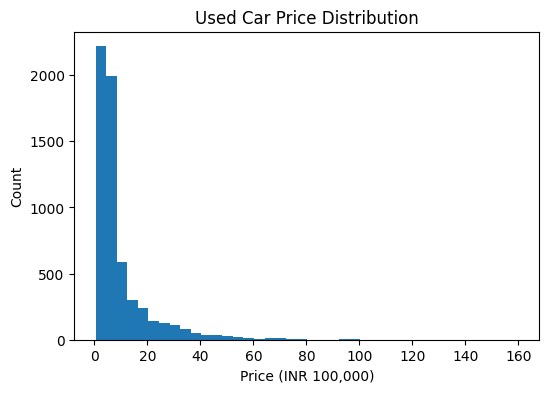

In [39]:
#Cell 26
plt.figure(figsize=(6,4))
plt.hist(df_train["Price"], bins=40)
plt.title("Used Car Price Distribution")
plt.xlabel("Price (INR 100,000)")
plt.ylabel("Count")
plt.show()

In [51]:
#Cell 27

# Features/target
X = df_train.drop(columns=["Price"])
y = df_train["Price"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_features = ["Year","Kilometers_Driven","Mileage","Engine","Power","Seats","Car_Age","Km_per_year"]
cat_features = ["Location","Fuel_Type","Transmission","Owner_Type","Brand"]  # keep Brand; Name is optional

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_features),
    ],
    remainder="drop"
)

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

ridge_model.fit(X_train, y_train)
pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
#rmse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"Ridge (raw Price) -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

Ridge (raw Price) -> MAE: 3.136, RMSE: 7.087, R2: 0.592


In [53]:
#Cell 28
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

ridge_log = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

ridge_log.fit(X_train, y_train_log)
pred_log = ridge_log.predict(X_test)

# Convert back to original price scale
pred_from_log = np.expm1(pred_log)

mae_log = mean_absolute_error(y_test, pred_from_log)
#rmse_log = mean_squared_error(y_test, pred_from_log)
rmse_log = root_mean_squared_error(y_test, pred_from_log)
r2_log = r2_score(y_test, pred_from_log)

print(f"Ridge (log Price) -> MAE: {mae_log:.3f}, RMSE: {rmse_log:.3f}, R2: {r2_log:.3f}")

Ridge (log Price) -> MAE: 1.833, RMSE: 4.799, R2: 0.813


In [48]:
#Cell 29
df_train2 = df_train.copy()

# Cap extreme kilometers (99th percentile)
km_cap = df_train2["Kilometers_Driven"].quantile(0.99)
df_train2["Kilometers_Driven"] = df_train2["Kilometers_Driven"].clip(upper=km_cap)

# Replace invalid mileage zeros
df_train2.loc[df_train2["Mileage"] == 0, "Mileage"] = np.nan
df_train2["Mileage"] = df_train2["Mileage"].fillna(df_train2["Mileage"].median())

# Replace unrealistic engine values (optional but recommended)
df_train2.loc[df_train2["Engine"] < 500, "Engine"] = np.nan
df_train2["Engine"] = df_train2["Engine"].fillna(df_train2["Engine"].median())

# Recompute Km_per_year with capped km
ref_year = df_train2["Year"].max()
df_train2["Car_Age"] = ref_year - df_train2["Year"]
df_train2["Km_per_year"] = df_train2["Kilometers_Driven"] / (df_train2["Car_Age"] + 1)